# Exercise 1.3 — Predict handwritten digits (MNIST, dense NN) — **solution**

Worked answers for `Exercise 1.3.ipynb`. Run it top to bottom; every cell is
self-contained apart from the ones that reuse `model` / `history`.

**MNIST facts:** 70,000 images (60k train / 10k test) of digits written by many different
people; the "Hello World" benchmark of image classification. The model here is a
two-layer dense network with ~16k parameters.

In [1]:
!pip install tensorflow matplotlib numpy scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# --- macOS certificate fix (safe no-op elsewhere) ---
# keras.datasets.*.load_data() downloads over HTTPS. The python.org macOS build
# ships without a default CA bundle, so the download fails with
# "CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate".
# Point Python at certifi's CA bundle. Harmless on Colab/Linux/Windows.
import os, certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())

'/Users/au263437/workspace/hih/_TinyML/Grundfoss/raw/tinyml-course_v2/exercises/.venv/lib/python3.11/site-packages/certifi/cacert.pem'

## Step 1 — Load and inspect the data

**Answers:** `x_train` is `(60000, 28, 28)` and `y_train` is `(60000,)` — the images are
**not** flattened yet, and the labels are plain integers `0-9`, not one-hot vectors
(that is why we use `sparse_categorical_crossentropy` later). Pixels are `uint8` in
`[0, 255]`. The classes are roughly balanced — between ~5,400 and ~6,700 samples each,
close enough that accuracy is a fair metric here. On the fan data in Module 4 that will
*not* be true, and it is the first thing to check.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

keras.utils.set_random_seed(42)          # so the numbers below are reproducible

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train:", x_train.shape, x_train.dtype, "min", x_train.min(), "max", x_train.max())
print("y_train:", y_train.shape, y_train.dtype, "labels", np.unique(y_train))
print("x_test: ", x_test.shape, " y_test:", y_test.shape)
print("samples per class:", np.bincount(y_train))

x_train: (60000, 28, 28) uint8 min 0 max 255
y_train: (60000,) uint8 labels [0 1 2 3 4 5 6 7 8 9]
x_test:  (10000, 28, 28)  y_test: (10000,)
samples per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


## Step 2 — Look at the data before you model it

Never train on data you have not looked at. Half the "the model doesn't learn" problems
in this course are visible with `imshow` and thirty seconds of attention.

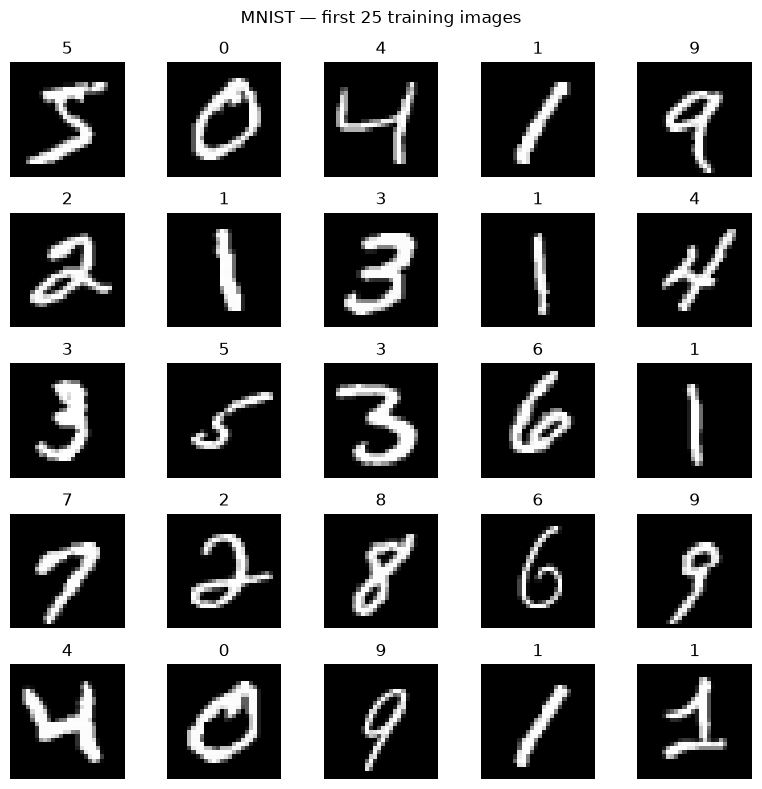

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, img, label in zip(axes.ravel(), x_train, y_train):
    ax.imshow(img, cmap="gray")
    ax.set_title(int(label))
    ax.axis("off")
fig.suptitle("MNIST — first 25 training images")
fig.tight_layout()

## Step 3 — Normalise

**Answer:** the network *could* learn the 1/255 scaling in its first-layer weights, but
it would have to do so by gradient descent — and the gradients for weights fed by inputs
of magnitude ~255 are ~255× larger than they would be for inputs of magnitude ~1. With
one global learning rate, that either explodes or forces the learning rate down for
every other weight in the network. Scaling the input is free; making the optimiser
discover it is not.

In [5]:
x_train = (x_train / 255.0).astype("float32")
x_test  = (x_test  / 255.0).astype("float32")
print("range now:", x_train.min(), "to", x_train.max(), x_train.dtype)

range now: 0.0 to 1.0 float32


## Step 4 — Build and train the model

The parameter count, by hand:

- `Dense(20)` on a 784-vector → `784 × 20 + 20` = **15,700**
- `Dense(10)` on a 20-vector → `20 × 10 + 10` = **210**
- total **15,910** ≈ 16k — which `model.summary()` should confirm exactly.

At 4 bytes per float32 that is ~62 KB of weights: it fits in the RAK4631's 1 MB flash
with room to spare. Hold that thought for Step 8.

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=2)

Epoch 1/10
1688/1688 - 1s - 563us/step - accuracy: 0.8825 - loss: 0.4205 - val_accuracy: 0.9473 - val_loss: 0.1914
Epoch 2/10
1688/1688 - 1s - 415us/step - accuracy: 0.9381 - loss: 0.2080 - val_accuracy: 0.9587 - val_loss: 0.1540
Epoch 3/10
1688/1688 - 1s - 423us/step - accuracy: 0.9499 - loss: 0.1714 - val_accuracy: 0.9618 - val_loss: 0.1383
Epoch 4/10
1688/1688 - 1s - 399us/step - accuracy: 0.9565 - loss: 0.1500 - val_accuracy: 0.9642 - val_loss: 0.1312
Epoch 5/10
1688/1688 - 1s - 403us/step - accuracy: 0.9607 - loss: 0.1354 - val_accuracy: 0.9650 - val_loss: 0.1271
Epoch 6/10
1688/1688 - 1s - 379us/step - accuracy: 0.9631 - loss: 0.1245 - val_accuracy: 0.9665 - val_loss: 0.1236
Epoch 7/10
1688/1688 - 1s - 379us/step - accuracy: 0.9656 - loss: 0.1160 - val_accuracy: 0.9672 - val_loss: 0.1211
Epoch 8/10
1688/1688 - 1s - 389us/step - accuracy: 0.9676 - loss: 0.1089 - val_accuracy: 0.9687 - val_loss: 0.1195
Epoch 9/10
1688/1688 - 1s - 390us/step - accuracy: 0.9696 - loss: 0.1030 - val_a

## Step 5 — Evaluate and plot the learning curves

**Answers:** test accuracy lands around **96-97 %** for this small 20-unit hidden layer
(a wider `Dense(128)` gets to 97-98 %). It should be close to the validation accuracy —
both are data the model never trained on, so a big gap between them would mean the
validation split is not representative.

The training curve keeps climbing after the validation curve flattens: the model is
starting to fit the training set specifically rather than digits in general. That is
**overfitting**, and the epoch where the curves separate is where early stopping would
cut you off.

test loss 0.1296   test accuracy 0.9620


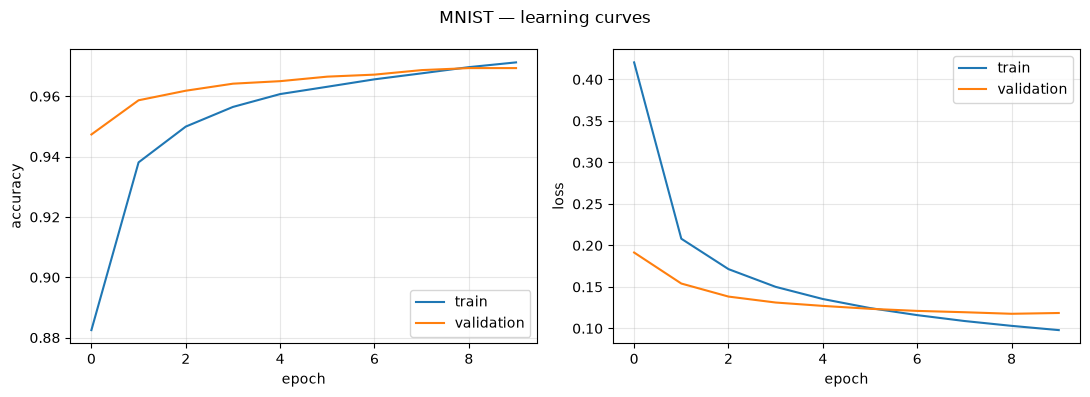

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"test loss {test_loss:.4f}   test accuracy {test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="validation")
ax1.set_xlabel("epoch"); ax1.set_ylabel("accuracy"); ax1.legend(); ax1.grid(alpha=.3)
ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="validation")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss"); ax2.legend(); ax2.grid(alpha=.3)
fig.suptitle("MNIST — learning curves")
fig.tight_layout()

## Step 6 — Break it on purpose

**Answers:** with the learning rate **×10** (`0.01`) the loss drops fast at first and then
bounces around a worse value — each step overshoots the minimum it is aiming at. With
**÷100** (`0.00001`) the loss decreases smoothly but is nowhere near converged after 10
epochs; it is simply taking steps too small to arrive.

This is the knob to reach for first when training misbehaves — and the reason loss curves
are worth plotting every single time.

In [9]:
def build_and_train(lr, epochs=10):
    keras.utils.set_random_seed(42)                 # same starting weights every time
    m = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
        keras.layers.Dense(20, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(x_train, y_train, epochs=epochs, validation_split=0.1, verbose=0)
    print(f"lr={lr:<10g} final train loss {h.history['loss'][-1]:.4f}"
          f"   val accuracy {h.history['val_accuracy'][-1]:.4f}")
    return h

runs = {lr: build_and_train(lr) for lr in (0.001, 0.01, 0.00001)}

lr=0.001      final train loss 0.0979   val accuracy 0.9693
lr=0.01       final train loss 0.1701   val accuracy 0.9437
lr=1e-05      final train loss 0.6051   val accuracy 0.8860


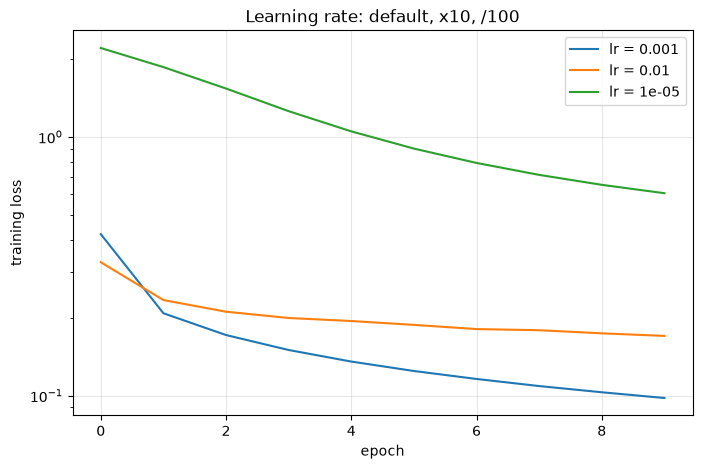

In [10]:
plt.figure(figsize=(8, 5))
for lr, h in runs.items():
    plt.plot(h.history["loss"], label=f"lr = {lr:g}")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.yscale("log")
plt.title("Learning rate: default, x10, /100")
plt.legend(); plt.grid(alpha=.3)

## Step 7 — Confusion matrix

**Answers:** the worst pairs in this run are **4→9** (24 of the 380 errors), **5→3**,
**9→4** and **7→2 / 7→3** — digits that share most of their strokes. The exact ranking
moves with the random seed, but the 4/9 pair and the 3/5/8 cluster always show up. They
are human mistakes: look at the misclassified images and you will argue with the ground
truth on a few of them.

What the matrix shows that accuracy hides is *where* the errors are. 96 % accuracy could
mean 4 % spread evenly, or one class being wrong nearly every time. On Day 3 this matters
more than it does here: a 3-class classifier fed a fault it has never seen will put that
sample confidently into one of its three boxes, and accuracy on the classes it *does*
know will look perfect.

true 4 predicted as 9: 24 times
true 5 predicted as 3: 19 times
true 9 predicted as 4: 17 times
true 7 predicted as 2: 15 times
true 7 predicted as 3: 14 times


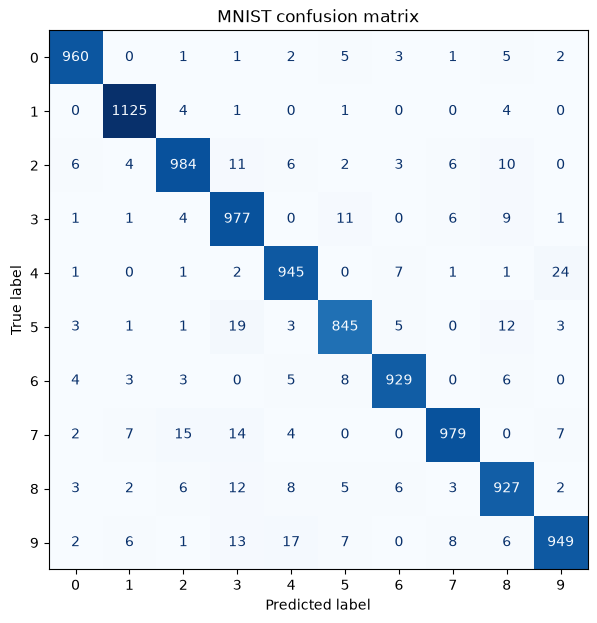

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_prob = model.predict(x_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("MNIST confusion matrix")

# the off-diagonal pairs the model confuses most often
off = cm.copy()
np.fill_diagonal(off, 0)
for true_d, pred_d in zip(*np.unravel_index(np.argsort(off, axis=None)[-5:][::-1], off.shape)):
    print(f"true {true_d} predicted as {pred_d}: {off[true_d, pred_d]} times")

380 misclassified out of 10000


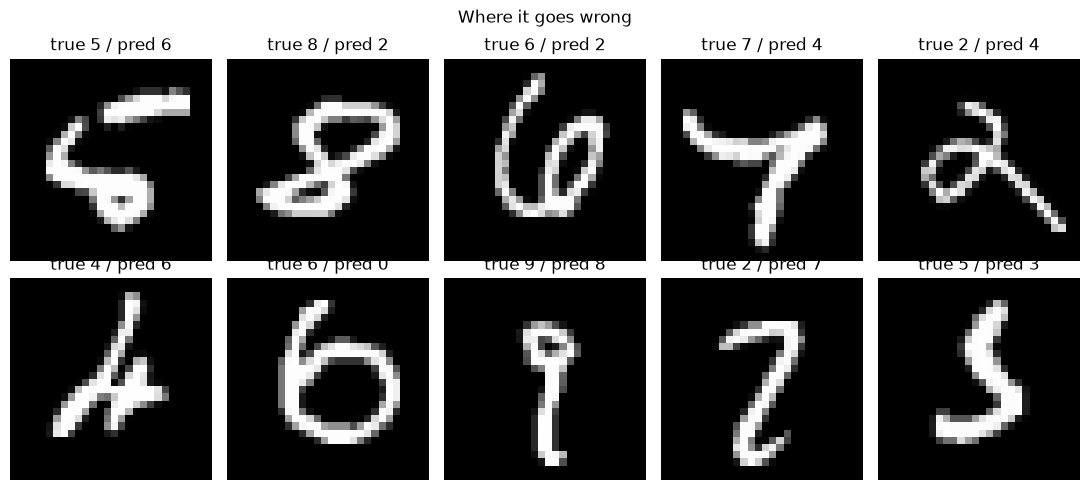

In [12]:
wrong = np.where(y_pred != y_test)[0]
print(f"{len(wrong)} misclassified out of {len(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, idx in zip(axes.ravel(), wrong[:10]):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"true {y_test[idx]} / pred {y_pred[idx]}")
    ax.axis("off")
fig.suptitle("Where it goes wrong")
fig.tight_layout()

## Step 8 — Save the model and open it in Netron

**Answers:** the ~16k parameters are `784×20 + 20` in the hidden layer and `20×10 + 10` in
the output layer — `Flatten` has none, it only reshapes. Netron shows the tensor shapes
between layers: `(None, 28, 28) → (None, 784) → (None, 20) → (None, 10)`.

At float32 the weights are ~62 KB — comfortable in the RAK4631's 1 MB flash, and about a
quarter of its 256 KB RAM if you loaded them there. Quantised to int8 (Module 9) it is
~16 KB. That is the whole game: the *model* is small enough, and what usually breaks the
budget is the input data and the activations, not the weights.

In [14]:
model.save("mnist_dense.keras")
params = model.count_params()
print(f"{params} parameters")
print(f"float32 weights: {params * 4 / 1024:.1f} KB")
print(f"int8 weights:    {params * 1 / 1024:.1f} KB")
print("RAK4631 budget:  1024 KB flash / 256 KB RAM")
# Now open mnist_dense.keras at https://netron.app/ — nothing is uploaded, it runs locally.

15910 parameters
float32 weights: 62.1 KB
int8 weights:    15.5 KB
RAK4631 budget:  1024 KB flash / 256 KB RAM


## Observe & discuss — the short answers

- **Learning rate up/down:** up → the loss oscillates or diverges; down → training crawls
  and never converges in a sensible number of epochs.
- **Confusion matrix:** it shows *which* classes are confused with which, i.e. the
  structure of the errors. Accuracy is a single number that averages that away.
- **What the network had to learn:** everything a feature engineer would have handed it —
  strokes, curvature, where ink is relative to the frame. It got 784 raw numbers and no
  hints, and paid for it in parameters.
- **Would it fit on the RAK4631?** The weights, easily. But you would also need the 784
  input floats and the layer activations in RAM, plus the inference runtime — and you
  would have to get a 28×28 image into a device that has an accelerometer and a
  microphone. Fitting is necessary, not sufficient.